In [1]:
pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 45.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import time
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from transformers import (
    AutoImageProcessor,
    SegformerForSemanticSegmentation,
    UperNetForSemanticSegmentation,
    DPTForSemanticSegmentation,
    Mask2FormerForUniversalSegmentation,
)

In [4]:
DATA_ROOT = "/content/drive/MyDrive/COMP9517/ass1/EWS-Dataset"
MODEL_TYPE = "segformer"

IMAGE_SIZE = 352
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
SEED = 42

SAVE_DIR = "/content/drive/MyDrive/ews_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

ID2LABEL = {0: "soil", 1: "wheat"}
LABEL2ID = {"soil": 0, "wheat": 1}
NUM_LABELS = 2

CHECKPOINTS = {
    "segformer": "nvidia/segformer-b0-finetuned-ade-512-512",
    "swin": "openmmlab/upernet-swin-tiny",
    "vit": "Intel/dpt-large-ade",
    "mask2former": "facebook/mask2former-swin-tiny-ade-semantic",
}

print("Using device:", DEVICE)
print("Model type:", MODEL_TYPE)
print("Data root:", DATA_ROOT)

Using device: cpu
Model type: segformer
Data root: /content/drive/MyDrive/COMP9517/ass1/EWS-Dataset


In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def find_subdir(root: Path, candidates):
    for name in candidates:
        p = root / name
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find any of {candidates} inside {root}")

def canonical_stem(path: Path):
    s = path.stem.lower()
    for suffix in ["_mask", "_label", "_labels", "_annotation", "_ann"]:
        if s.endswith(suffix):
            s = s[: -len(suffix)]
    return s.rstrip("_-")

def load_binary_mask(mask_path: str):
    mask = Image.open(mask_path).convert("L")
    mask = np.array(mask)
    mask = (mask > 127).astype(np.uint8)
    return mask

set_seed(SEED)

In [6]:
class EWSSegmentationDataset(Dataset):
    def __init__(self, split_dir, processor, model_type):
        self.split_dir = Path(split_dir)
        self.processor = processor
        self.model_type = model_type

        # Add '.' to candidates to allow for images/masks directly in the split_dir
        image_candidates = ["images", "image", "imgs", "img", "rgb", "."]
        mask_candidates = ["masks", "mask", "labels", "label", "annotations", "annotation", "."]

        image_dir = find_subdir(self.split_dir, image_candidates)
        mask_dir = find_subdir(self.split_dir, mask_candidates)

        image_files = []
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
            image_files.extend(sorted(image_dir.glob(ext)))

        mask_files = []
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
            mask_files.extend(sorted(mask_dir.glob(ext)))

        if not image_files or not mask_files:
            raise RuntimeError(f"No images or masks found in {self.split_dir}")

        mask_map = {canonical_stem(p): p for p in mask_files}
        self.samples = []

        for img_path in image_files:
            key = canonical_stem(img_path)
            if key in mask_map:
                self.samples.append((str(img_path), str(mask_map[key])))

        if len(self.samples) == 0:
            if len(image_files) != len(mask_files):
                raise RuntimeError(
                    "Could not pair images and masks by filename, and counts do not match."
                )
            self.samples = [(str(i), str(m)) for i, m in zip(sorted(image_files), sorted(mask_files))]

        print(f"{self.split_dir.name}: {len(self.samples)} image/mask pairs found")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, mask_path = self.samples[idx]

        image = Image.open(image_path).convert("RGB")
        orig_mask_np = load_binary_mask(mask_path)
        orig_h, orig_w = orig_mask_np.shape

        seg_map = Image.fromarray(orig_mask_np.astype(np.uint8))

        encoded = self.processor(
            images=image,
            segmentation_maps=seg_map,
            return_tensors="pt",
            do_resize=True,
            size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
            do_reduce_labels=False,
        )

        item = {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "orig_mask": torch.from_numpy(orig_mask_np).long(),
            "orig_size": (orig_h, orig_w),
            "image_id": Path(image_path).stem,
        }

        if self.model_type == "mask2former":
            item["pixel_mask"] = encoded["pixel_mask"].squeeze(0)
            item["mask_labels"] = encoded["mask_labels"][0]
            item["class_labels"] = encoded["class_labels"][0]
        else:
            labels = encoded["labels"]
            if labels.ndim == 3:
                labels = labels.squeeze(0)
            item["labels"] = labels.long()

        return item

In [7]:
def make_collate_fn(model_type):
    def collate_fn(batch):
        out = {
            "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
            "orig_masks": [x["orig_mask"] for x in batch],
            "orig_sizes": [x["orig_size"] for x in batch],
            "image_ids": [x["image_id"] for x in batch],
        }

        if model_type == "mask2former":
            out["pixel_mask"] = torch.stack([x["pixel_mask"] for x in batch])
            out["mask_labels"] = [x["mask_labels"] for x in batch]
            out["class_labels"] = [x["class_labels"] for x in batch]
        else:
            out["labels"] = torch.stack([x["labels"] for x in batch])

        return out
    return collate_fn


def build_processor_and_model(model_type):
    ckpt = CHECKPOINTS[model_type]

    processor = AutoImageProcessor.from_pretrained(
        ckpt,
        do_reduce_labels=False,
    )

    common_kwargs = dict(
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    if model_type == "segformer":
        model = SegformerForSemanticSegmentation.from_pretrained(ckpt, **common_kwargs)
    elif model_type == "swin":
        model = UperNetForSemanticSegmentation.from_pretrained(ckpt, **common_kwargs)
    elif model_type == "vit":
        model = DPTForSemanticSegmentation.from_pretrained(ckpt, **common_kwargs)
    elif model_type == "mask2former":
        model = Mask2FormerForUniversalSegmentation.from_pretrained(ckpt, **common_kwargs)
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {model_type}")

    return processor, model


def compute_binary_metrics(tp, fp, fn, tn):
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-8)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "accuracy": accuracy,
    }


def update_confusion_counts(pred_mask, true_mask, counts):
    pred = pred_mask.view(-1)
    true = true_mask.view(-1)

    counts["tp"] += int(((pred == 1) & (true == 1)).sum().item())
    counts["fp"] += int(((pred == 1) & (true == 0)).sum().item())
    counts["fn"] += int(((pred == 0) & (true == 1)).sum().item())
    counts["tn"] += int(((pred == 0) & (true == 0)).sum().item())

In [8]:
def forward_loss(model, batch, model_type):
    if model_type == "mask2former":
        outputs = model(
            pixel_values=batch["pixel_values"].to(DEVICE),
            pixel_mask=batch["pixel_mask"].to(DEVICE),
            mask_labels=[x.to(DEVICE) for x in batch["mask_labels"]],
            class_labels=[x.to(DEVICE) for x in batch["class_labels"]],
        )
    else:
        outputs = model(
            pixel_values=batch["pixel_values"].to(DEVICE),
            labels=batch["labels"].to(DEVICE),
        )
    return outputs


@torch.no_grad()
def predict_batch(model, processor, batch, model_type):
    if model_type == "mask2former":
        outputs = model(
            pixel_values=batch["pixel_values"].to(DEVICE),
            pixel_mask=batch["pixel_mask"].to(DEVICE),
        )
        preds = processor.post_process_semantic_segmentation(
            outputs,
            target_sizes=batch["orig_sizes"],
        )
        preds = [p.cpu().long() for p in preds]
    else:
        outputs = model(pixel_values=batch["pixel_values"].to(DEVICE))
        logits = outputs.logits
        preds = []

        for i, (h, w) in enumerate(batch["orig_sizes"]):
            resized = F.interpolate(
                logits[i].unsqueeze(0),
                size=(h, w),
                mode="bilinear",
                align_corners=False,
            )
            pred = resized.argmax(dim=1).squeeze(0).cpu().long()
            preds.append(pred)

    return preds


def train_one_epoch(model, loader, optimizer, model_type):
    model.train()
    total_loss = 0.0

    for batch in loader:
        optimizer.zero_grad()
        outputs = forward_loss(model, batch, model_type)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate(model, processor, loader, model_type):
    model.eval()
    total_loss = 0.0
    counts = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}

    for batch in loader:
        outputs = forward_loss(model, batch, model_type)
        total_loss += outputs.loss.item()

        preds = predict_batch(model, processor, batch, model_type)
        for pred, target in zip(preds, batch["orig_masks"]):
            update_confusion_counts(pred, target, counts)

    metrics = compute_binary_metrics(**counts)
    metrics["loss"] = total_loss / max(len(loader), 1)
    return metrics

In [9]:
processor, model = build_processor_and_model(MODEL_TYPE)
model.to(DEVICE)

train_set = EWSSegmentationDataset(Path(DATA_ROOT) / "train", processor, MODEL_TYPE)
val_set = EWSSegmentationDataset(Path(DATA_ROOT) / "validation", processor, MODEL_TYPE)
test_set = EWSSegmentationDataset(Path(DATA_ROOT) / "test", processor, MODEL_TYPE)

collate_fn = make_collate_fn(MODEL_TYPE)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print("Model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


train: 284 image/mask pairs found
validation: 48 image/mask pairs found
test: 48 image/mask pairs found
Model loaded successfully.


In [10]:
best_val_iou = -1.0
best_path = os.path.join(SAVE_DIR, f"{MODEL_TYPE}_best.pt")

train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, MODEL_TYPE)
    val_metrics = evaluate(model, processor, val_loader, MODEL_TYPE)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_iou={val_metrics['iou']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f} | "
        f"val_precision={val_metrics['precision']:.4f} | "
        f"val_recall={val_metrics['recall']:.4f}"
    )

    if val_metrics["iou"] > best_val_iou:
        best_val_iou = val_metrics["iou"]
        torch.save(
            {
                "epoch": epoch,
                "model_type": MODEL_TYPE,
                "model_state_dict": model.state_dict(),
                "val_metrics": val_metrics,
            },
            best_path,
        )

train_time = time.time() - train_start
print(f"\nTraining complete. Best model saved to: {best_path}")
print(f"Training time: {train_time:.2f} seconds")

Epoch 01/20 | train_loss=0.4716 | val_loss=0.3322 | val_iou=0.8199 | val_f1=0.9011 | val_precision=0.9388 | val_recall=0.8663
Epoch 02/20 | train_loss=0.2835 | val_loss=0.2545 | val_iou=0.8704 | val_f1=0.9307 | val_precision=0.9608 | val_recall=0.9024
Epoch 03/20 | train_loss=0.2095 | val_loss=0.2082 | val_iou=0.8863 | val_f1=0.9397 | val_precision=0.9797 | val_recall=0.9029
Epoch 04/20 | train_loss=0.1789 | val_loss=0.1622 | val_iou=0.9166 | val_f1=0.9565 | val_precision=0.9596 | val_recall=0.9534
Epoch 05/20 | train_loss=0.1530 | val_loss=0.1407 | val_iou=0.9289 | val_f1=0.9631 | val_precision=0.9680 | val_recall=0.9583
Epoch 06/20 | train_loss=0.1394 | val_loss=0.1343 | val_iou=0.9332 | val_f1=0.9654 | val_precision=0.9633 | val_recall=0.9676
Epoch 07/20 | train_loss=0.1272 | val_loss=0.1277 | val_iou=0.9319 | val_f1=0.9648 | val_precision=0.9731 | val_recall=0.9566
Epoch 08/20 | train_loss=0.1173 | val_loss=0.1187 | val_iou=0.9367 | val_f1=0.9673 | val_precision=0.9703 | val_recall

In [11]:
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

test_start = time.time()
test_metrics = evaluate(model, processor, test_loader, MODEL_TYPE)
test_time = time.time() - test_start

print("\n===== FINAL TEST RESULTS =====")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

print(f"\nTesting time: {test_time:.2f} seconds")


===== FINAL TEST RESULTS =====
precision: 0.9713
recall: 0.9677
f1: 0.9695
iou: 0.9408
accuracy: 0.9591
loss: 0.1076

Testing time: 22.69 seconds


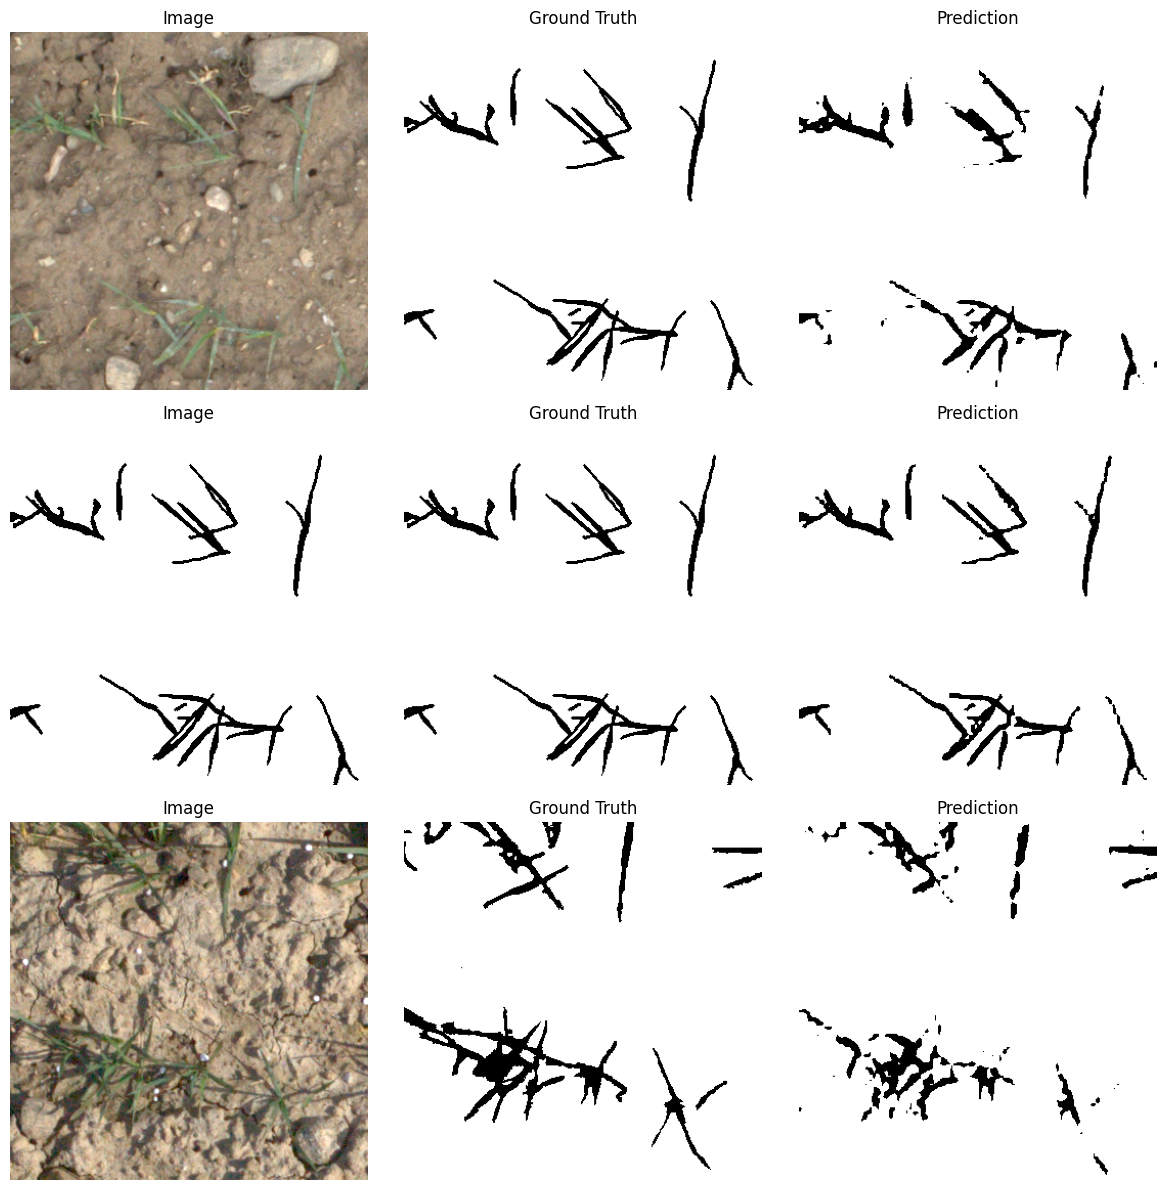

In [12]:
import matplotlib.pyplot as plt

@torch.no_grad()
def show_predictions(model, processor, dataset, model_type, num_samples=3):
    model.eval()
    plt.figure(figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        item = dataset[i]

        pixel_values = item["pixel_values"].unsqueeze(0).to(DEVICE)
        orig_mask = item["orig_mask"].cpu().numpy()
        orig_size = item["orig_size"]

        if model_type == "mask2former":
            pixel_mask = item["pixel_mask"].unsqueeze(0).to(DEVICE)
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)
            pred = processor.post_process_semantic_segmentation(
                outputs, target_sizes=[orig_size]
            )[0].cpu().numpy()
        else:
            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            resized = F.interpolate(
                logits,
                size=orig_size,
                mode="bilinear",
                align_corners=False,
            )
            pred = resized.argmax(dim=1).squeeze(0).cpu().numpy()

        img_path, _ = dataset.samples[i]
        image = np.array(Image.open(img_path).convert("RGB"))

        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(image)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(orig_mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, processor, test_set, MODEL_TYPE, num_samples=3)